In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import seaborn as sns
from causal_graph_comparison import *

Detected non-Linux system, using scratch directory:  /Users/cisaicu/dev/mila/scratch


In [5]:
results_path = f"{SCRATCH_DIR}/results/SAVAR_DATA_TEST/STAR-var_savar_scen_piControl_nlinmix_False_nlindyn_False_tau_5_z_4_futt_1_ldec_1_lr_0.001_bs_256_ormuin_100000.0_spmuin_0.1_spth_0.05_nens_2_inst_False_crpscoef_1_sspcoef_0_tspcoef_0_fracnhiwn_0.5_nummix_0_numhid_0_embdim_10/trajectory_iteration_1199.npy"

picabu_output = np.load(results_path)

print(picabu_output.shape)


(50, 8, 1, 1600)


In [12]:
# Reshape targets to 40x40
picabu_data = picabu_output[:,0,0,:]
picabu_reshaped = picabu_data.reshape(50, 40, 40)
print(picabu_reshaped.shape)

(50, 40, 40)


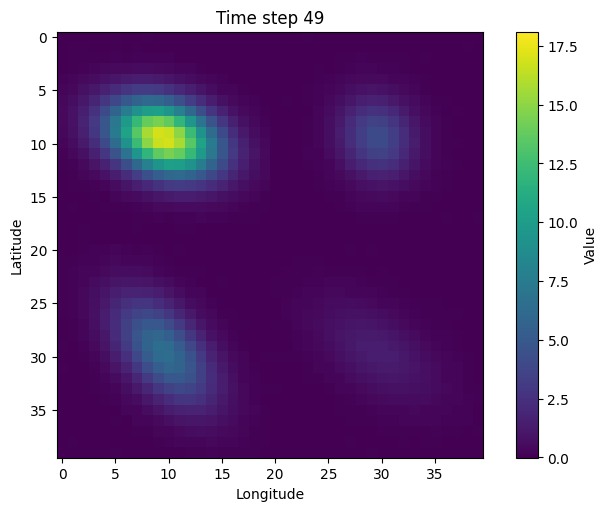

In [14]:
# Reshape targets to 40x40

vmin = picabu_data.min()
vmax = picabu_data.max()

# Create figure with subplots for target and output comparison
fig, (ax1) = plt.subplots(1, 1, figsize=(7, 5))

# Initialize heatmaps with same vmin/vmax
im1 = ax1.imshow(picabu_reshaped[0, :, :], cmap='viridis', vmin=vmin, vmax=vmax)

# Add colorbars to both plots with same scale
plt.colorbar(im1, ax=ax1, label='Value')

ax1.set_xlabel('Longitude')
ax1.set_ylabel('Latitude')

plt.tight_layout()

# Animation update function
def update(frame):

    im1.set_array(picabu_reshaped[frame, :, :])
    ax1.set_title(f'Time step {frame}')
    return [im1]

# Create animation
anim = FuncAnimation(fig, update, frames=50, interval=1000, repeat=True, blit=True)

from IPython.display import HTML
HTML(anim.to_jshtml())
